In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import glob
hits = glob.glob('/content/drive/MyDrive/**/VAT_Cleaned_5Years.xlsx', recursive=True)
print(hits)

['/content/drive/MyDrive/VAT Project/VAT_Cleaned_5Years.xlsx']


In [3]:
import pandas as pd
import numpy as np

PATH = "/content/drive/MyDrive/VAT Project/VAT_Cleaned_5Years.xlsx"
clean = pd.read_excel(PATH, sheet_name=None)
purchases = clean["Purchases"].copy()
sales     = clean["Sales"].copy()

print("Purchases:", purchases.shape, "| Sales:", sales.shape)
print("date dtype:", purchases["date"].dtype, "| amount dtype:", purchases["amount_aed"].dtype)

Purchases: (420, 8) | Sales: (5793, 7)
date dtype: datetime64[ns] | amount dtype: float64


In [4]:
for df in (purchases, sales):
    df["year"] = df["date"].dt.year
    df["quarter"] = df["date"].dt.to_period("Q").astype(str)

print(purchases["year"].value_counts().sort_index())

year
2020    79
2021    90
2022    83
2023    89
2024    79
Name: count, dtype: int64


In [5]:
p_year = purchases.groupby("year").agg(
    purchase_amount=("amount_aed", "sum"),
    purchase_vat=("vat_5_aed", "sum"),
).round(2)

s_year = sales.groupby("year").agg(
    sales_amount=("amount_aed", "sum"),
    sales_vat=("vat_5_aed", "sum"),
).round(2)

yearly = p_year.join(s_year)
print(yearly)

      purchase_amount  purchase_vat  sales_amount  sales_vat
year                                                        
2020        122506.19       6125.32     198056.16    9902.78
2021        155303.80       7765.20     222414.65   11120.78
2022        125859.18       6292.98     248698.70   12435.03
2023        143603.50       7180.18     279870.68   13993.56
2024        131703.77       6585.17     311658.09   15582.84


In [6]:
yearly["net_vat_payable"] = (yearly["sales_vat"] - yearly["purchase_vat"]).round(2)
yearly["gross_profit"]    = (yearly["sales_amount"] - yearly["purchase_amount"]).round(2)

print(yearly[["sales_amount", "purchase_amount", "gross_profit", "net_vat_payable"]])

print("\nTotal over 5 years:")
print("  Total Sales:        AED", yearly["sales_amount"].sum().round(2))
print("  Total Purchases:    AED", yearly["purchase_amount"].sum().round(2))
print("  Total Gross Profit: AED", yearly["gross_profit"].sum().round(2))
print("  Total VAT Payable:  AED", yearly["net_vat_payable"].sum().round(2))

growth = (yearly["sales_amount"].iloc[-1] - yearly["sales_amount"].iloc[0]) / yearly["sales_amount"].iloc[0] * 100
print(f"\nSales growth 2020→2024: {growth:.1f}%")

      sales_amount  purchase_amount  gross_profit  net_vat_payable
year                                                              
2020     198056.16        122506.19      75549.97          3777.46
2021     222414.65        155303.80      67110.85          3355.58
2022     248698.70        125859.18     122839.52          6142.05
2023     279870.68        143603.50     136267.18          6813.38
2024     311658.09        131703.77     179954.32          8997.67

Total over 5 years:
  Total Sales:        AED 1260698.28
  Total Purchases:    AED 678976.44
  Total Gross Profit: AED 581721.84
  Total VAT Payable:  AED 29086.14

Sales growth 2020→2024: 57.4%


In [7]:
# top suppliers by total spend
top_suppliers = (purchases.groupby("supplier_name")["amount_aed"]
                 .sum().round(2).sort_values(ascending=False).head(10))
print("Top 10 Suppliers by Spend:")
print(top_suppliers)

print()

# top services by total revenue
top_services = (sales.groupby("service")["amount_aed"]
                .sum().round(2).sort_values(ascending=False))
print("Services by Revenue:")
print(top_services)

Top 10 Suppliers by Spend:
supplier_name
Al Danah Real Estate              441697.44
Jumbo Electronics                  62054.23
Abu Dhabi Distribution Company     48102.97
Etisalat                           31625.57
Du Telecom                         27457.93
Canon Middle East                  24316.26
Unknown Supplier                   11722.72
Adobe Systems                       6883.72
Sharaf Stationery                   5886.31
Gulf Maintenance Co                 4903.24
Name: amount_aed, dtype: float64

Services by Revenue:
service
PRO Services                  310112.45
Arabic-English Translation    192149.71
Document Attestation          158131.57
Visa Application Typing       125984.62
TAMM Transaction              121692.48
Tas-heel Transaction           88951.96
Labour Contract Typing         86335.38
Typing Services                83809.21
Emirates ID Typing             57637.89
Printing & Photocopy           27267.75
Arabic-English Translaton       8625.26
Name: amount_aed

In [8]:
sales["service"] = sales["service"].replace(
    {"Arabic-English Translaton": "Arabic-English Translation"})

# re-run the groupby to confirm it merged
top_services = (sales.groupby("service")["amount_aed"]
                .sum().round(2).sort_values(ascending=False))
print("Services by Revenue (fixed):")
print(top_services)

Services by Revenue (fixed):
service
PRO Services                  310112.45
Arabic-English Translation    200774.97
Document Attestation          158131.57
Visa Application Typing       125984.62
TAMM Transaction              121692.48
Tas-heel Transaction           88951.96
Labour Contract Typing         86335.38
Typing Services                83809.21
Emirates ID Typing             57637.89
Printing & Photocopy           27267.75
Name: amount_aed, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.family"]    = "DejaVu Sans"
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

BLUE   = "#2B6CB0"
GREEN  = "#276749"
RED    = "#9B2335"
GOLD   = "#B7791F"

print("Matplotlib ready")

Matplotlib ready


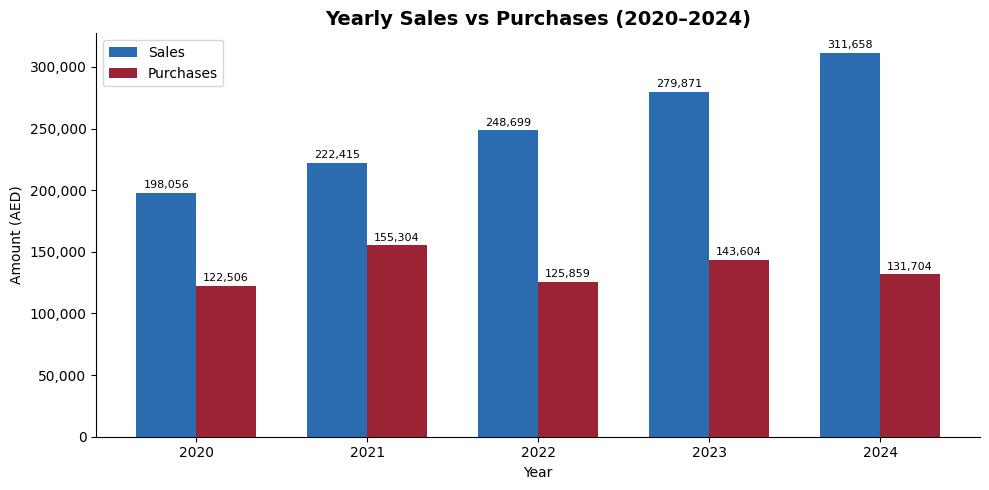

Chart 1 saved


In [10]:
fig, ax = plt.subplots()

x = yearly.index
width = 0.35
bars1 = ax.bar(x - width/2, yearly["sales_amount"], width, label="Sales", color=BLUE)
bars2 = ax.bar(x + width/2, yearly["purchase_amount"], width, label="Purchases", color=RED)

ax.set_title("Yearly Sales vs Purchases (2020–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Amount (AED)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f"{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f"{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/VAT Project/chart1_sales_vs_purchases.png", dpi=150)
plt.show()
print("Chart 1 saved")

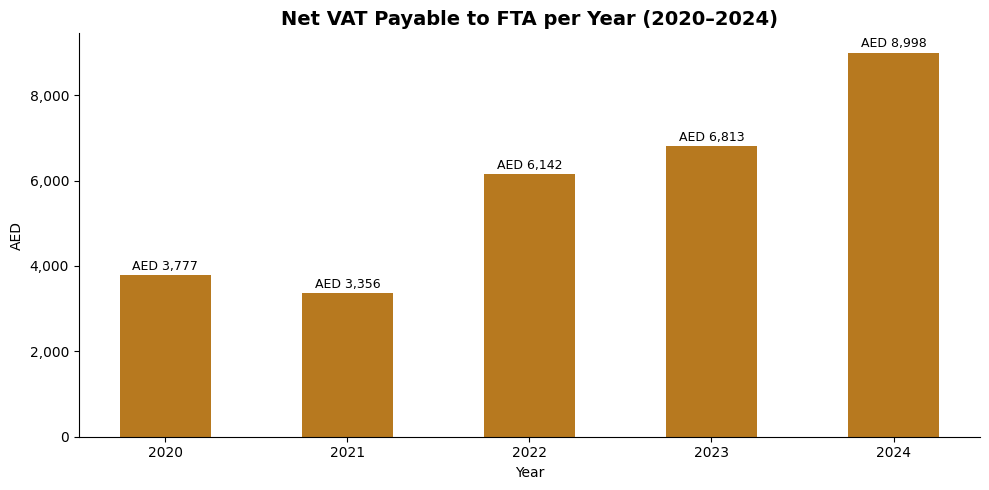

Chart 2 saved


In [11]:
fig, ax = plt.subplots()

bars = ax.bar(yearly.index, yearly["net_vat_payable"], color=GOLD, width=0.5)

ax.set_title("Net VAT Payable to FTA per Year (2020–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("AED")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"AED {bar.get_height():,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/VAT Project/chart2_net_vat_payable.png", dpi=150)
plt.show()
print("Chart 2 saved")

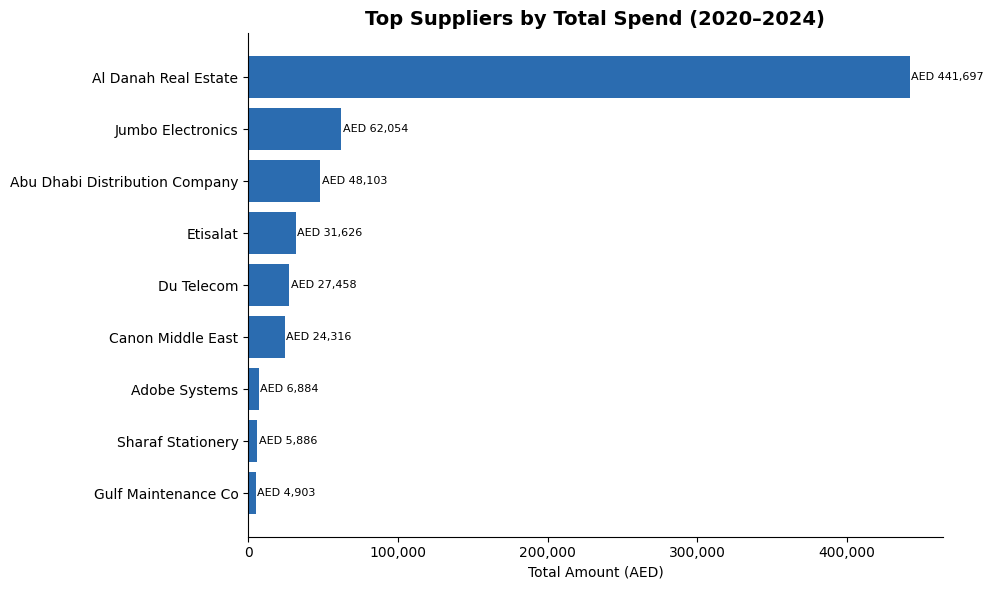

Chart 3 saved


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

suppliers = top_suppliers.drop("Unknown Supplier", errors="ignore")
ax.barh(suppliers.index[::-1], suppliers.values[::-1], color=BLUE)

ax.set_title("Top Suppliers by Total Spend (2020–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Amount (AED)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for i, (val, name) in enumerate(zip(suppliers.values[::-1], suppliers.index[::-1])):
    ax.text(val + 1000, i, f"AED {val:,.0f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/VAT Project/chart3_top_suppliers.png", dpi=150)
plt.show()
print("Chart 3 saved")

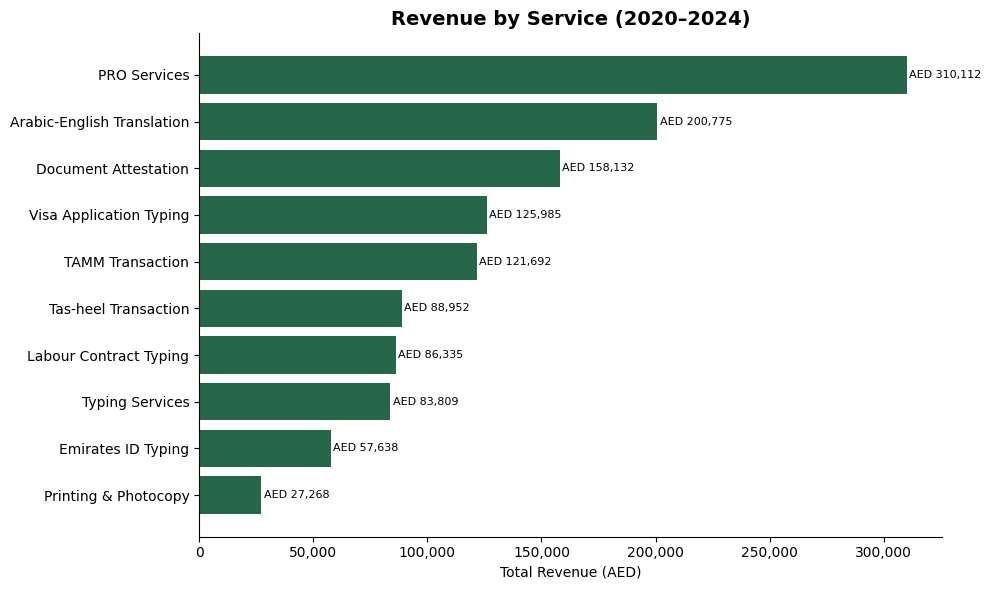

Chart 4 saved


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_services.index[::-1], top_services.values[::-1], color=GREEN)

ax.set_title("Revenue by Service (2020–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (AED)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for i, (val, name) in enumerate(zip(top_services.values[::-1], top_services.index[::-1])):
    ax.text(val + 1000, i, f"AED {val:,.0f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/VAT Project/chart4_services_revenue.png", dpi=150)
plt.show()
print("Chart 4 saved")

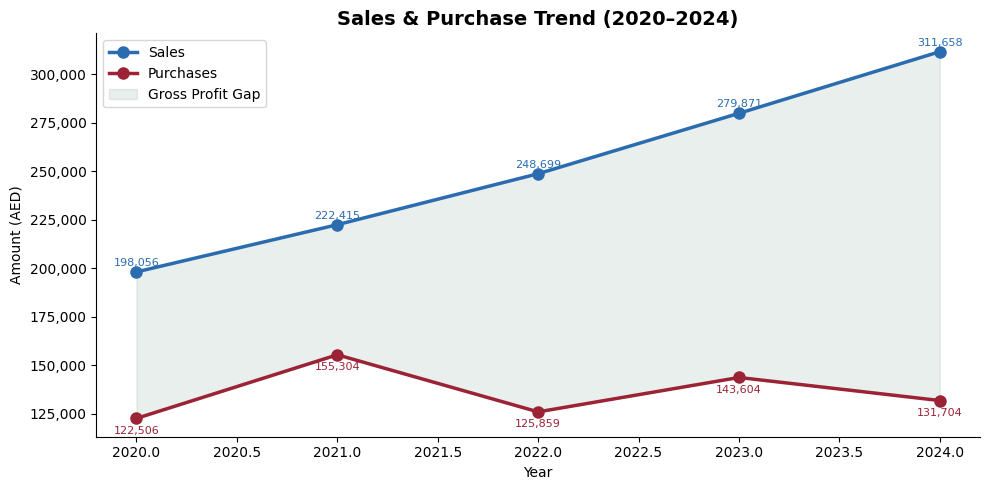

Chart 5 saved


In [14]:
fig, ax = plt.subplots()

ax.plot(yearly.index, yearly["sales_amount"], color=BLUE,
        marker="o", linewidth=2.5, markersize=8, label="Sales")
ax.plot(yearly.index, yearly["purchase_amount"], color=RED,
        marker="o", linewidth=2.5, markersize=8, label="Purchases")
ax.fill_between(yearly.index, yearly["purchase_amount"],
                yearly["sales_amount"], alpha=0.1, color=GREEN, label="Gross Profit Gap")

ax.set_title("Sales & Purchase Trend (2020–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Amount (AED)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()

for x, y in zip(yearly.index, yearly["sales_amount"]):
    ax.text(x, y + 3000, f"{y:,.0f}", ha="center", fontsize=8, color=BLUE)
for x, y in zip(yearly.index, yearly["purchase_amount"]):
    ax.text(x, y - 8000, f"{y:,.0f}", ha="center", fontsize=8, color=RED)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/VAT Project/chart5_growth_trend.png", dpi=150)
plt.show()
print("Chart 5 saved")

In [15]:
with pd.ExcelWriter("/content/drive/MyDrive/VAT Project/VAT_Analysis_Results.xlsx") as w:
    yearly.to_excel(w, sheet_name="Yearly Summary")
    top_suppliers.to_excel(w, sheet_name="Top Suppliers")
    top_services.to_excel(w, sheet_name="Top Services")

print("Analysis results saved")

Analysis results saved


In [16]:
purchases["month"] = purchases["date"].dt.to_period("M").astype(str)
sales["month"] = sales["date"].dt.to_period("M").astype(str)

monthly_sales = (sales.groupby("month")["amount_aed"]
                 .sum().round(2).reset_index())
monthly_sales.columns = ["month", "sales_amount"]

# add to your results Excel
with pd.ExcelWriter("/content/drive/MyDrive/VAT Project/VAT_Analysis_Results.xlsx",
                    mode="a", if_sheet_exists="replace") as w:
    monthly_sales.to_excel(w, sheet_name="Monthly Sales", index=False)

print(monthly_sales.tail(10))

      month  sales_amount
50  2024-03      28056.15
51  2024-04      25531.41
52  2024-05      22716.02
53  2024-06      25237.90
54  2024-07      25893.54
55  2024-08      26536.44
56  2024-09      27052.40
57  2024-10      23846.83
58  2024-11      30427.11
59  2024-12      30329.38


In [17]:
import pandas as pd
check = pd.read_excel("/content/drive/MyDrive/VAT Project/VAT_Analysis_Results.xlsx",
                      sheet_name=None)
print("Sheets in file:", list(check.keys()))

Sheets in file: ['Yearly Summary', 'Top Suppliers', 'Top Services', 'Monthly Sales']
